category
Women Ethnic Wear         4.056551e+07
Men's Fashion             3.439111e+07
Home & Kitchen            3.063104e+07
Footwear                  3.033241e+07
Bags & Luggage            1.468311e+07
Mobile Accessories        1.391906e+07
Beauty & Personal Care    1.214895e+07
Jewellery                 1.150361e+07
Kids Wear                 5.156680e+06
Name: total_amount, dtype: float64


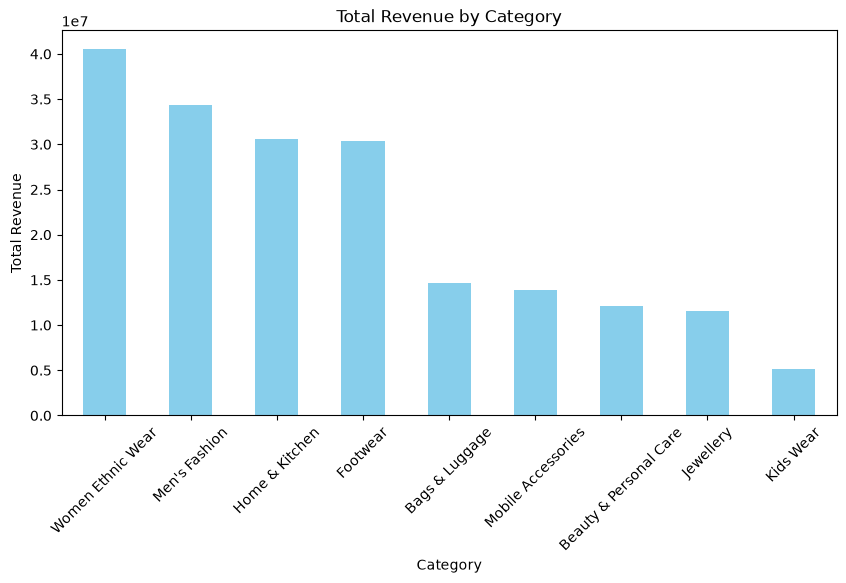

month
2023-01    8.825583e+06
2023-02    4.604415e+06
2023-03    5.300375e+06
2023-04    5.188424e+06
2023-05    6.743771e+06
2023-06    5.318889e+06
2023-07    5.471787e+06
2023-08    8.150862e+06
2023-09    5.221528e+06
2023-10    1.705275e+07
2023-11    1.092129e+07
2023-12    7.857615e+06
2024-01    9.780624e+06
2024-02    5.858986e+06
2024-03    5.923796e+06
2024-04    5.924417e+06
2024-05    7.763063e+06
2024-06    5.964646e+06
2024-07    5.906540e+06
2024-08    9.098466e+06
2024-09    5.774120e+06
2024-10    1.923622e+07
2024-11    1.234074e+07
2024-12    9.102579e+06
Freq: M, Name: total_amount, dtype: float64


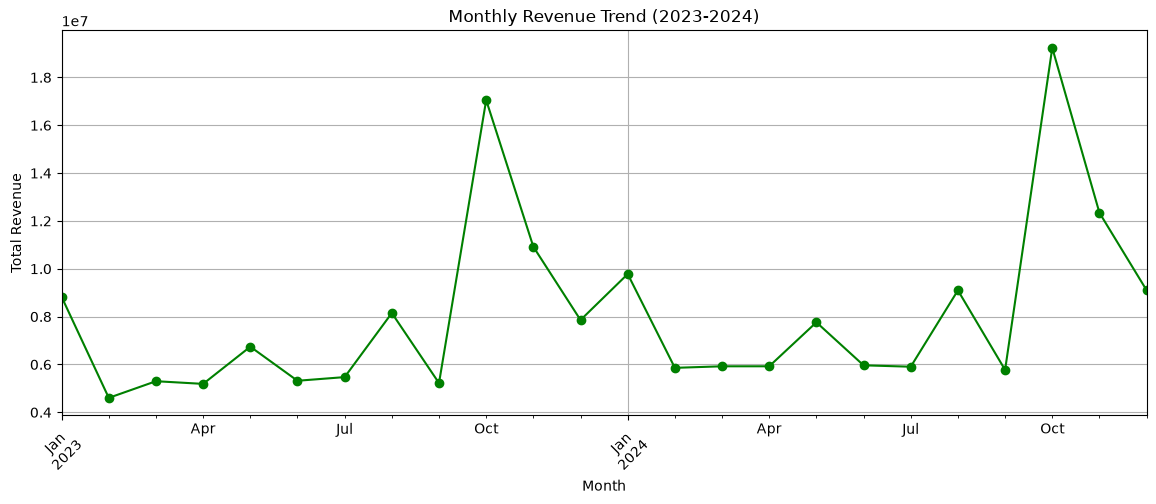

payment_mode
COD        16.846013
Prepaid     9.583928
Name: return_status, dtype: float64


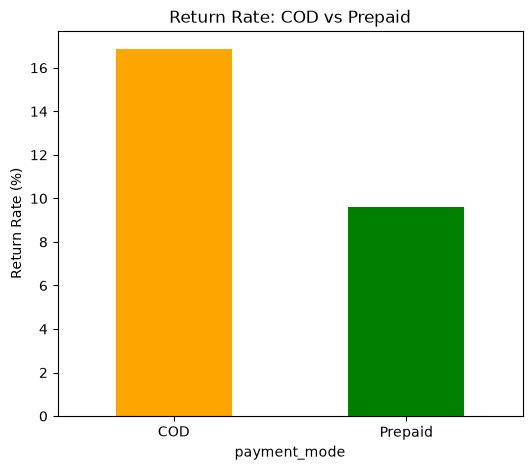

city_tier
Tier 3    1939.250807
Tier 2    1934.365368
Tier 1    1927.070605
Name: total_amount, dtype: float64


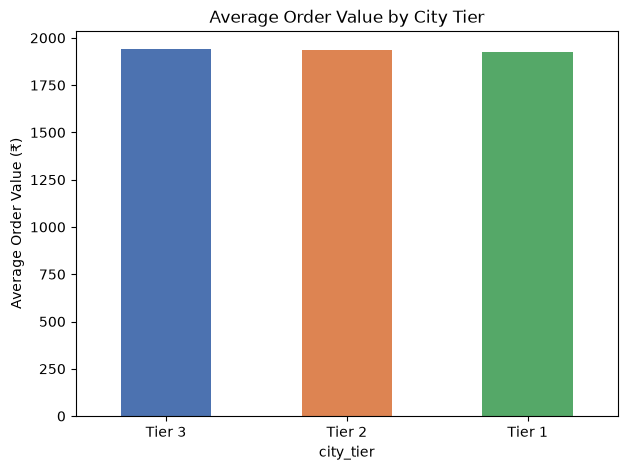

discount_bucket
0-10%     12.678104
10-20%    13.369944
20-30%    13.396708
30-40%    13.814667
40-50%    17.719916
50%+      16.277890
Name: return_status, dtype: float64


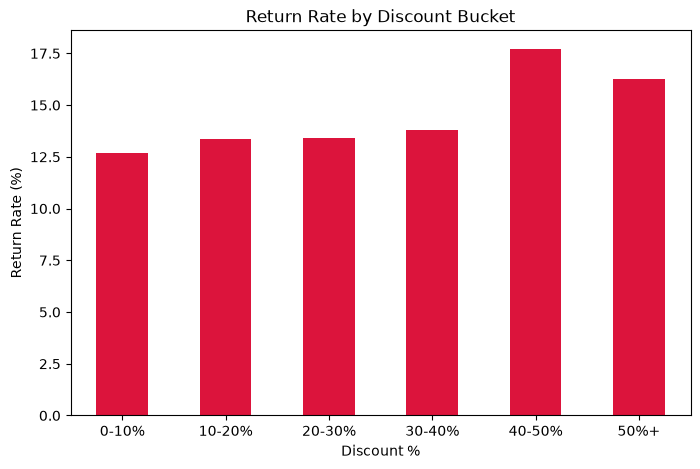

customer_type
New       6.938681e+06
Repeat    1.863928e+08
Name: total_amount, dtype: float64


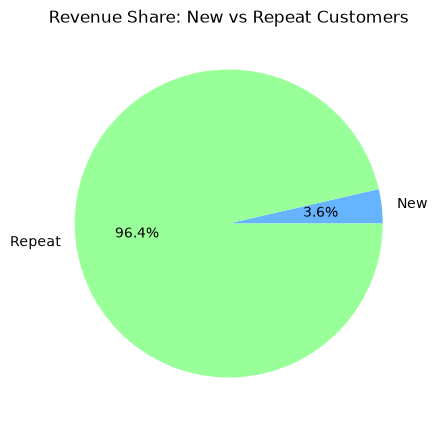

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ecommerce_cleaned.csv')
df.head()
df['total_amount'] = df['quantity'] * df['price']
df.head()
category_revenue = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)
print(category_revenue)
plt.figure(figsize=(10,5))
category_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.savefig('../plots/total_revenue_by_category.png', bbox_inches='tight', dpi=150)
plt.show()
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['total_amount'].sum()
print(monthly_revenue)
monthly_revenue = df.groupby('month')['total_amount'].sum()

plt.figure(figsize=(14,5))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend (2023-2024)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('../plots/monthly_revenue_trend.png', bbox_inches='tight', dpi=150)
plt.show()
return_rate = df.groupby('payment_mode')['return_status'].apply(lambda x: (x=='Returned').mean()*100)
print(return_rate)

plt.figure(figsize=(6,5))
return_rate.plot(kind='bar', color=['orange','green'])
plt.title('Return Rate: COD vs Prepaid')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)
plt.savefig('../plots/return_rate_cod_prepaid.png', bbox_inches='tight', dpi=150)
plt.show()
tier_aov = df.groupby('city_tier')['total_amount'].mean().sort_values(ascending=False)
print(tier_aov)

plt.figure(figsize=(7,5))
tier_aov.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Average Order Value by City Tier')
plt.ylabel('Average Order Value (₹)')
plt.xticks(rotation=0)
plt.savefig('../plots/aov_by_tier.png', bbox_inches='tight', dpi=150)
plt.show()
df['discount_bucket'] = pd.cut(df['discount_percent'], bins=[0,10,20,30,40,50,100], 
                                 labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50%+'])

discount_return = df.groupby('discount_bucket')['return_status'].apply(lambda x: (x=='Returned').mean()*100)
print(discount_return)

plt.figure(figsize=(8,5))
discount_return.plot(kind='bar', color='crimson')
plt.title('Return Rate by Discount Bucket')
plt.xlabel('Discount %')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)
plt.savefig('../plots/discount_vs_return.png', bbox_inches='tight', dpi=150)
plt.show()
customer_order_count = df.groupby('customer_id')['order_id'].count()
repeat_customers = customer_order_count[customer_order_count > 1].index

df['customer_type'] = df['customer_id'].apply(lambda x: 'Repeat' if x in repeat_customers else 'New')

customer_revenue = df.groupby('customer_type')['total_amount'].sum()
print(customer_revenue)

plt.figure(figsize=(6,5))
customer_revenue.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Revenue Share: New vs Repeat Customers')
plt.ylabel('')
plt.savefig('../plots/new_vs_repeat_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

## Insight: Revenue Share - New vs Repeat Customers

96.4% revenue repeat customers se aata hai, sirf 3.6% naye customers 
se.

**Business takeaway:** Business bahut zyada repeat-customer-dependent 
hai — yeh retention ke liye achha signal hai, lekin naye customer 
acquisition bhi badhana zaroori hai taki growth sirf existing base 
tak limited na rahe.

## Insight: Return Rate by Discount Bucket

Discount 0-30% tak return rate stable hai (~12.7-13.4%), lekin 40% 
se zyada discount pe return rate 17.7% tak badh jata hai.

**Business takeaway:** Heavy discounting (40%+) zyada returns laata 
hai — shayad customers "impulse buy" karte hain aur baad mein return 
kar dete hain. Deep discounts sirf carefully selected categories mein 
hi dene chahiye.

## Insight: Average Order Value by City Tier

Teeno tiers (Tier 1, 2, 3) ka AOV lagbhag same hai (~₹1,925-₹1,940) — 
koi significant difference nahi hai tier ke hisaab se.

**Business takeaway:** Spending pattern city tier se independent hai — 
matlab Tier 2/3 customers bhi utna hi kharch karte hain jitna Tier 1, 
isliye marketing sirf metro cities tak limited nahi honi chahiye.

## Insight: Return Rate by Payment Mode

COD orders ka return rate 16.8% hai, jabki Prepaid orders ka sirf 
9.6% — matlab COD orders mein returns ~75% zyada hote hain.

**Business takeaway:** High-value COD orders ke liye confirmation 
call ya partial advance payment introduce karne se returns kam ho 
sakte hain, jisse logistics cost bachegi.

## Insight: Monthly Revenue Trend

October-November mein har saal bada spike dikh raha hai (2023 mein 
~₹1.7 Cr, 2024 mein ~₹1.9 Cr) — yeh Diwali/festive season se match 
karta hai. Baaki mahine revenue stable rehta hai (~₹0.5-0.9 Cr).

**Business takeaway:** Festive season (Oct-Nov) normal months se 
2-3x zyada revenue deta hai — inventory stocking aur ad-spend 
planning 4-6 hafte pehle shuru honi chahiye.

Category-wise Revenue Insight:

Women Ethnic Wear sabse zyada revenue generate karti hai (~4.05 crore), 
uske baad Men's Fashion. Kids Wear sabse kam contribute karti hai.

Business takeaway: Top categories par marketing aur inventory focus 
karna chahiye.